# Testing and OO programming exercises 7/10/2026

## Brais Otero Lema

In the testing exercises the notebook magics are commented so that it does not mess with my local filesystem, they will need to be uncommented.

Exercise 1.1. Counting calls.

In [2]:
from functools import wraps, lru_cache

def count_calls(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        wrapper.calls += 1
        return func(*args, **kwargs)
    wrapper.calls = 0
    return wrapper

@count_calls
def naive_fib_rec(n):
    if n < 2:
        return n
    return naive_fib_rec(n-1) + naive_fib_rec(n-2)

@count_calls
@lru_cache
def cached_naive_fib_rec(n):
    if n < 2:
        return n
    return cached_naive_fib_rec(n-1) + cached_naive_fib_rec(n-2)

@lru_cache
@count_calls
def inv_cached_naive_fib_rec(n):
    if n < 2:
        return n
    return inv_cached_naive_fib_rec(n-1) + inv_cached_naive_fib_rec(n-2)

print_ns = (10, 20, 25)
for print_n in print_ns:
    naive_fib_rec.calls, cached_naive_fib_rec.calls, inv_cached_naive_fib_rec.calls = 0, 0, 0
    
    naive_fib_rec(print_n)
    cached_naive_fib_rec(print_n)
    inv_cached_naive_fib_rec(print_n)

    print(f"Fibonacci({print_n})")
    print(f"Naive calls: {naive_fib_rec.calls}")
    print(f"Cached calls: {cached_naive_fib_rec.calls}")
    print(f"Inverted calls: {inv_cached_naive_fib_rec.calls}")
    print(25*"-")


Fibonacci(10)
Naive calls: 177
Cached calls: 19
Inverted calls: 0
-------------------------
Fibonacci(20)
Naive calls: 21891
Cached calls: 21
Inverted calls: 0
-------------------------
Fibonacci(25)
Naive calls: 242785
Cached calls: 11
Inverted calls: 0
-------------------------


When the decorators are inverted, the calls shown are zero because *lru_cache* does not have a *calls* attribute. It can be accessed nonetheless through the *lru\_cache.\_\_wrapped\_\_* attribute, which stores the function being enveloped by the decorator, which in the inverted case is the *count_calls* decorator. This is shown in the cell below.

In [3]:
print(f"Inverted calls correctly accessed: {inv_cached_naive_fib_rec.__wrapped__.calls}")

Inverted calls correctly accessed: 26


Exercise 1.2. Poisson testing.

In [ ]:
# %%writefile poisson.py

from numpy import exp
from scipy.special import factorial
poisson = lambda n, mu : mu**n * exp(-mu) / factorial(n)

In [ ]:
# %%writefile test_poisson.py

import pytest
from numpy import exp
from poisson import poisson

if __name__ == "__main__":
    def test_poisson(mu):
        assert sum(poisson(n, mu) for n in range(0, 51)) == pytest.approx(1)
        assert sum(n*poisson(n, mu) for n in range(0, 51)) == pytest.approx(mu)
        assert poisson(0, mu) == pytest.approx(exp(-mu))

    test_poisson(5)
    print("Test for mu=5 successful!")

@pytest.mark.parametrize("mu", range(0, 11))
def test_poisson(mu):
    assert sum(poisson(n, mu) for n in range(0, 51)) == pytest.approx(1)
    assert sum(n*poisson(n, mu) for n in range(0, 51)) == pytest.approx(mu)
    assert poisson(0, mu) == pytest.approx(exp(-mu))


In [ ]:
import sys
!{sys.executable} -m pytest -q test_poisson.py

Exercise 2.1. List and tuple methods.

In [4]:
methods = []
for list_method in dir(list):
    if not list_method in dir(tuple):
        methods.append(list_method)
print(f"The following methods are in class list but not in class tuple:\n{methods}")
print("Note that they are the ones relative to adding or removing elements, or changing the order, since tuples are immutable!")

The following methods are in class list but not in class tuple:
['__delitem__', '__iadd__', '__imul__', '__reversed__', '__setitem__', 'append', 'clear', 'copy', 'extend', 'insert', 'pop', 'remove', 'reverse', 'sort']
Note that they are the ones relative to adding or removing elements, or changing the order, since tuples are immutable!


Exercise 2.2. Fractions module.

In [5]:
import fractions
from numpy import isclose

f_13, f_64 = fractions.Fraction(1, 3), fractions.Fraction(6, 4)

print(dir(fractions.Fraction))

fh_10 = sum(fractions.Fraction(1, k) for k in range(1, 11))
h_10 = sum(1/k for k in range(1, 11))

print(f"\nExact result with fractions: H_10 = {fh_10}")
print(f"Result with floats: H_10 = {h_10}")
print(f"numpy.isclose -> {isclose(fh_10, h_10)}")

print(f"\nFraction(0.1) = {fractions.Fraction(.1)}")
print(f"Fraction({repr("0.1")}) = {fractions.Fraction(".1")}")
print("They differ because for the float a specific exact conversion is used; this is shown in help(Fraction).")


['__abs__', '__abstractmethods__', '__add__', '__bool__', '__ceil__', '__class__', '__complex__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__firstlineno__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__le__', '__lt__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__pos__', '__pow__', '__radd__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmod__', '__rmul__', '__round__', '__rpow__', '__rsub__', '__rtruediv__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__trunc__', '_abc_impl', '_add', '_denominator', '_div', '_divmod', '_floordiv', '_format_float_style', '_format_general', '_from_coprime_ints', '_mod', '_mul', '_numerator', '_operator_fallbacks', '_richcmp', '_sub', 'as_integ

Exercise 3.1. Vector class.

In [ ]:
# %%writefile class_vector.py

class Vector:

    """
    Vector custom class. Components are stored as a list.
    """

    def __init__(self, components):
        if not all([isinstance(c, (float, int)) for c in components]):
            raise TypeError("all components must be numbers")
        self.components = [c for c in components]

    def __len__(self):
        return len(self.components)
    
    def __getitem__(self, key):
        return self.components[key]

    def __repr__(self):
        return f"Vector({str(self.components)})"

    @classmethod
    def from_single_value(cls, value, dimension):
        if not isinstance(value, (float, int)):
            raise TypeError("value must be a number")
        return cls([value for _ in range(dimension)])

    def __add__(self, other):
        if isinstance(other, (float, int)):
            other = Vector.from_single_value(other, len(self))
        if not isinstance(other, Vector):
            return NotImplemented
        return Vector([s + o for s, o in zip(self.components, other.components)])

    def __sub__(self, other):
        return self.__add__(other * -1)

    def __eq__(self, other):
        if not isinstance(other, Vector):
            other = Vector.from_single_value(other, len(self))
        return all([s == o for s, o in zip(self.components, other.components)])

    def __mul__(self, value):
        if not isinstance(value, (float, int)):
            return NotImplemented
        return Vector([c * value for c in self.components])

    def __rmul__(self, value):
        return self * value

    def dot(self, other):
        if not isinstance(other, Vector):
            return NotImplemented
        return sum([s * o for s, o in zip(self.components, other.components)])

    def __abs__(vector):
        if not isinstance(vector, Vector):
            return NotImplemented
        return vector.dot(vector)**.5


Exercise 3.2. Histogram class.

In [6]:
class Histogram:
    """
    Histogram custom class.
    """

    def __init__(self, nbins, xmin, xmax):
        if not isinstance(nbins, int):
            raise TypeError("nbins must be an integer")
        if not (isinstance(xmin, (int, float)) and isinstance(xmax, (int, float))):
            raise TypeError("xmin and xmax must both be numbers")
        if xmin >= xmax:
            raise ValueError("xmax must be greater than xmin")
        
        self.nbins = nbins
        self.xmin = xmin
        self.xmax = xmax

        self.bin_size = (self.xmax - self.xmin) / self.nbins

        self.counts = [0 for _ in range(nbins)]

    @property
    def entries(self):
        return sum(self.counts)

    def fill(self, x):
        if self.xmin <= x <= self.xmax:
            bin_index = int((x - self.xmin) // self.bin_size)
            self.counts[bin_index] += 1

    def mean(self):
        return sum([i*self.bin_size/2 * c for i, c in enumerate(self.counts)]) / self.nbins

    def __str__(self):
        return "".join([f"{c*"*"}\n" for c in self.counts])

if __name__ == "__main__":
    hist = Histogram(12, -3, 3)
    from random import gauss
    for _ in range(1000):
        hist.fill(gauss())
    print(hist)


***
****************
*****************************************
**************************************************************************************************
**************************************************************************************************************************************************************
*************************************************************************************************************************************************************************************
***************************************************************************************************************************************************************************************************************
***********************************************************************************************************************************************************
*******************************************************************************************
*****************************
***********

Exercise 4.1. Testing vector class.

In [ ]:
# %%writefile test_class_vector.py
import pytest
from class_vector import Vector

@pytest.mark.parametrize("u, v", [(Vector([1,2]), Vector([3,4])), (Vector([5,6]), Vector([7, 8]))])
def test_class_vector(u, v):
    assert u + v == v + u
    assert v - v == 0
    assert 2 * u == u + u
    assert abs(v)**2 == pytest.approx(v.dot(v))


In [ ]:
import sys
!{sys.executable} -m pytest -q test_class_vector.py

Exercise 4.2. Potentials.

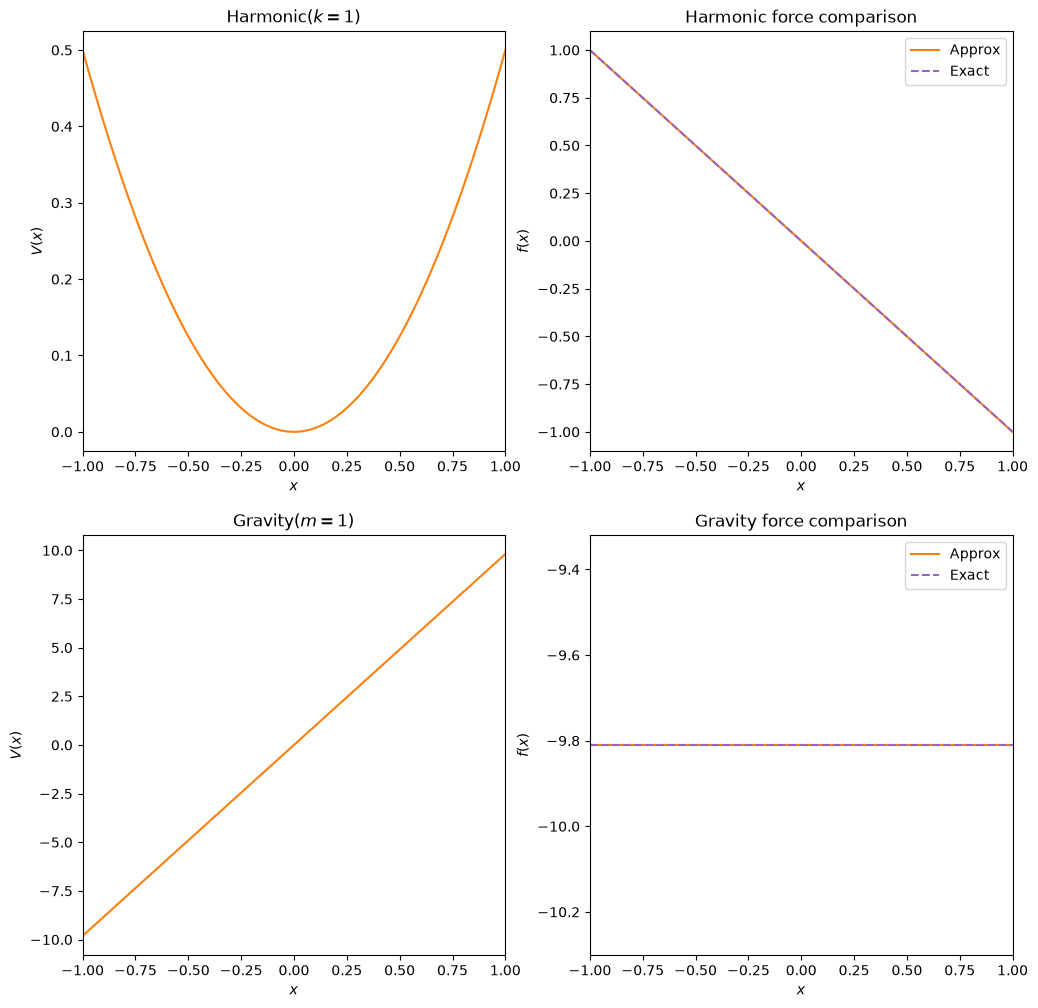

In [7]:
from abc import ABC, abstractmethod

class Potential1D(ABC):
    """
    Abstract base class for one-dimensional potentials.
    """

    @abstractmethod
    def V(self, x):
        """
        Returns the potential at a given point x.
        """

    def force(self, x, h=1e-5):
        """
        Computes the force at a given point x using a central difference.
        """
        return -1 * ((self.V(x + h) - self.V(x - h)) / 2 / h)

    def describe(self):
        """
        Returns a string with the name.
        """
        return f"{type(self).__name__}"

class Harmonic(Potential1D):
    """
    Harmonic potential class. Derived from Potential1D.
    """

    def __init__(self, k):
        if not isinstance(k, (float, int)):
            raise TypeError("k must be a number")
        if not k > 0:
            raise ValueError("k must be a positive number")

        self.k = k

    def V(self, x):
        return .5 * self.k * x**2

class Gravity(Potential1D):
    """
    Gravity potential class. Derived from Potential1D.
    """

    def __init__(self, m , g=9.81):
        if not isinstance(g, (float, int)):
            raise TypeError("g must be a number")
        if not isinstance(m, (float, int)):
            raise TypeError("m must be a number")
        if not m > 0:
            raise ValueError("m must be a positive number")

        self.m = m
        self.g = g

    def V(self, x):
        return self.m * self.g * x

if __name__ == "__main__":

    harm = Harmonic(1)
    grav = Gravity(1)

    from numpy import linspace
    xlin = linspace(-1, 1, 1000)

    from matplotlib.pyplot import subplot_mosaic
    fig, axs = subplot_mosaic([["hv", "hf"], ["gv", "gf"]], figsize=((12, 12)))

    axs["hv"].plot(xlin, harm.V(xlin), ls="solid", color="tab:orange")
    axs["hv"].set_ylabel(r"$V(x)$")
    axs["hv"].set_title("Harmonic($k=1$)")

    axs["hf"].plot(xlin, harm.force(xlin), ls="solid", color="tab:orange", label="Approx")
    axs["hf"].plot(xlin, -harm.k * xlin, ls="dashed", color="tab:purple", label="Exact")
    axs["hf"].set_ylabel(r"$f(x)$")
    axs["hf"].set_title("Harmonic force comparison")
    axs["hf"].legend(loc="best")

    axs["gv"].plot(xlin, grav.V(xlin), ls="solid", color="tab:orange")
    axs["gv"].set_ylabel(r"$V(x)$")
    axs["gv"].set_title("Gravity($m=1$)")

    axs["gf"].plot(xlin, grav.force(xlin), ls="solid", color="tab:orange", label="Approx")
    axs["gf"].axhline(-grav.m * grav.g, ls="dashed", color="tab:purple", label="Exact")
    axs["gf"].set_ylabel(r"$f(x)$")
    axs["gf"].set_title("Gravity force comparison")
    axs["gf"].legend(loc="best")
    axs["gf"].set_ylim(bottom=-1.05*grav.g, top=-.95*grav.g) # or else it gets crazy

    for name in axs:
        axs[name].set_xlim(left=min(xlin), right=max(xlin))
        axs[name].set_xlabel(r"$x$")
